In [112]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load data

In [113]:
save_name_modifier = "_delete" # "", "_ablation", "_ablation_small"

In [114]:
dataset_name = 'GB1'
MAX_FITNESS = 8.76196565571

y_limits = [0., 8.8]
y_limits_wt = [1., 8.85]
CLADE = True

In [115]:
# dataset_name = 'PhoQ'
# MAX_FITNESS = 133.59427

# y_limits = [0., 60.]
# y_limits_wt = [0., 70.]
# CLADE = True

In [116]:
# dataset_name = 'TrpB'
# MAX_FITNESS = 1.0 # Dataset is already normalized.

# y_limits = [0., 1.01]
# y_limits_wt = [0., 1.01]
# CLADE = False

In [117]:
labels = []

# DE benchmarks
smw_file_name = 'de/smw_'+dataset_name+'_all.pkl'
labels.append('SMW')
recombine_file_name = 'de/recombination_'+dataset_name+'.pkl'
labels.append('Recombination')

# BOES
DIM = 1280
boes_file_names = []
# boes_file_names.append('boes/'+dataset_name+'/original_1280.pkl')
# labels.append('BOES matérn32')
boes_file_names.append('boes/'+dataset_name+'/matern_'+str(DIM)+'.pkl')
labels.append('BOES matérn12')
# boes_file_names.append('boes/'+dataset_name+'/conic_'+str(DIM)+'.pkl')
# labels.append('BOES cylidrical')
# boes_file_names.append('boes/'+dataset_name+'/additive_'+str(DIM)+'.pkl')
# labels.append('BOES additive')

# BOES ablation study
# boes_file_names.append('boes/'+dataset_name+'/onehot.pkl')
# labels.append('BOES onehot')
# boes_file_names.append('boes/'+dataset_name+'/ucb.pkl')
# labels.append('BOES ucb')
# boes_file_names.append('boes/'+dataset_name+'/ucb_onehot.pkl')
# labels.append('BOES ucb onehot')

# ODBO
# odbo_file_names = []
# odbo_file_names.append('odbo/results/'+dataset_name+'_BO_GP_all.pkl')
# labels.append('ODBO BO GP')
# odbo_file_names.append('odbo/results/'+dataset_name+'_ODBO_TuRBO_RobustGP_all.pkl')
# labels.append('ODBO full')

# # CLADE
# if CLADE:
#     clade_file_name = 'clade/' + dataset_name + '/budget_190/fitness_progressions.npy'
#     labels.append('CLADE 2.0')

In [118]:
all_fitness_progressions = []

with open("../PELLM/data/"+dataset_name+"/sampled_starting_variants_1000.pkl", 'rb') as f:
    sampled_starting_variants = pickle.load(f)[0]

# DE benchmarks
with open(smw_file_name, 'rb') as f:
    smw_start_variants, smw_final_variants, smw_fitness_progressions = pickle.load(f)
#all_fitness_progressions.append(np.array(smw_fitness_progressions))
filtered_smw_fitness_progressions = []
for variant in sampled_starting_variants[0:100]:
    if variant in smw_start_variants:
        index = smw_start_variants.index(variant)
        filtered_smw_fitness_progressions.append(smw_fitness_progressions[index])
all_fitness_progressions.append(np.array(filtered_smw_fitness_progressions))

with open(recombine_file_name, 'rb') as f:
    recombine_best_variants, recombine_fitness_progressions = pickle.load(f)
def unify_fitness_progressions(fitness_progressions):
    """ rfpl = []
    for i in range(len(fitness_progressions)):
        rfpl.append(len(fitness_progressions[i]))
    max_rfpl = max(rfpl) """
    max_rfpl = 191
    for i in range(len(fitness_progressions)):
        fitness_progressions[i] = fitness_progressions[i] + (max_rfpl - len(fitness_progressions[i]))*[fitness_progressions[i][-1]]
        fitness_progressions[i] = fitness_progressions[i][0:max_rfpl]
    return fitness_progressions
recombine_fitness_progressions = unify_fitness_progressions(recombine_fitness_progressions)
all_fitness_progressions.append(np.array(recombine_fitness_progressions[0:100]))

# BOES
for file_name in boes_file_names:
    with open(file_name, 'rb') as f:
        boes_fitness_progressions = np.array(pickle.load(f)[0]) * MAX_FITNESS
    all_fitness_progressions.append(boes_fitness_progressions)

# # ODBO
# for file_name in odbo_file_names:
#     with open(file_name, 'rb') as f:
#         odbo_fitness_progressions = np.array(pickle.load(f)) * MAX_FITNESS
#     all_fitness_progressions.append(odbo_fitness_progressions)

# # CLADE
# if CLADE:
#     with open(clade_file_name, 'rb') as f:
#         clade_fitness_progressions = np.load(f) * MAX_FITNESS
#     all_fitness_progressions.append(clade_fitness_progressions)

In [119]:
print(len(all_fitness_progressions))

3


In [120]:
# CLADE
if CLADE:
    clade_data_dists = {}
    for budget in [50, 100, 150, 190]:
        clade_file_name = 'clade/'+dataset_name+'/budget_'+str(budget)+'/max_fitnesses.npy'
        with open(clade_file_name, 'rb') as f:
            _dist = np.load(f) * MAX_FITNESS
        clade_data_dists[budget] = _dist

# Plot CDF and final fitnesses

In [121]:
all_counts = []
all_bins = []
all_bin_centers = []

all_sorted_fitnesses = []
all_cdf_values = []

def prepare_final_fitnesses(fitness_progressions):
    final_fitnesses = []
    for progression in fitness_progressions:
        final_fitnesses.append(progression[-1])

    return final_fitnesses

def prepare_cdf_data(final_fitnesses):
    final_fitnesses_sorted = np.sort(final_fitnesses)
    n = len(final_fitnesses_sorted)
    cdf_values = 1. * np.arange(n) / (n - 1)

    all_sorted_fitnesses.append(final_fitnesses_sorted)
    all_cdf_values.append(cdf_values)

for fp in all_fitness_progressions:
    prepare_cdf_data(prepare_final_fitnesses(fp))


In [122]:
all_means = []
all_medians = []
all_first_q = []
all_third_q = []
for fitness in all_sorted_fitnesses:
    all_means.append(np.mean(fitness))
    all_medians.append(np.median(fitness))
    all_first_q.append(np.quantile(fitness, 0.25))
    all_third_q.append(np.quantile(fitness, 0.75))

print(labels)
print(all_means)
print(all_first_q)
print(all_medians)
print(all_third_q)

['SMW', 'Recombination', 'BOES matérn12']
[np.float64(5.058421479674271), np.float64(4.8202308832), np.float64(8.616076475933518)]
[np.float64(4.21629688093), np.float64(3.9486066944775002), np.float64(8.76196565571)]
[np.float64(5.296814594004999), np.float64(4.86273341601), np.float64(8.76196565571)]
[np.float64(6.5513396534275), np.float64(5.59337922227), np.float64(8.76196565571)]


/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_40855/1245041734.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axs[0].boxplot(


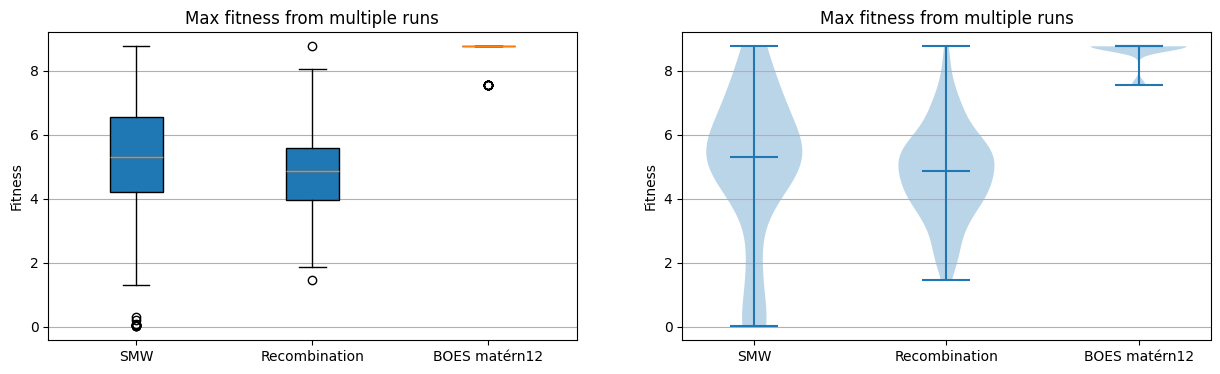

In [123]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
bplot = axs[0].boxplot(
    all_sorted_fitnesses,
    vert=True,  # vertical box alignment
    patch_artist=True,  # fill with color
    labels=labels,
)

axs[1].violinplot(all_sorted_fitnesses,
                  showmeans=False,
                  showmedians=True)
axs[1].set_title('Violin plot')

for ax in axs:
    ax.set_title("Max fitness from multiple runs")
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(all_sorted_fitnesses))],
                  labels=labels)
    #ax.set_xlabel('')
    ax.set_ylabel('Fitness')

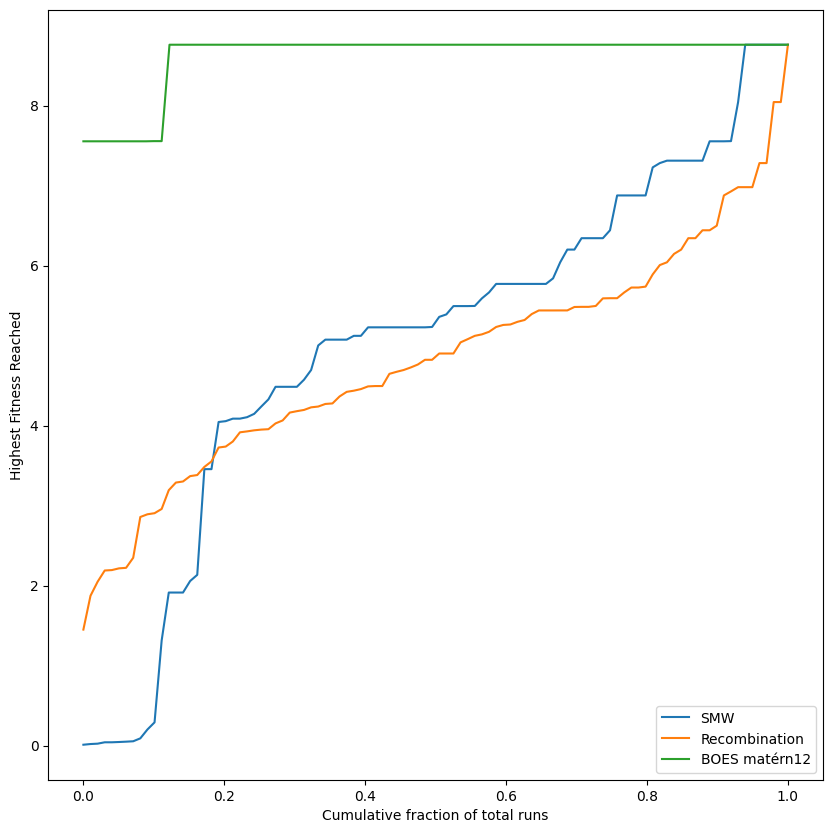

In [124]:
assert len(all_cdf_values) == len(all_sorted_fitnesses)

fig = plt.figure(figsize=(10, 10))
for i in range(len(all_cdf_values)):
    plt.plot(
        all_cdf_values[i],
        all_sorted_fitnesses[i],
        #color=colors[i] if len(colors) > i else None,
    )
plt.legend(labels)
plt.xlabel("Cumulative fraction of total runs")
plt.ylabel("Highest Fitness Reached")
#plt.title("Performance of traditional DE methods")
#fig.axes[0].set_aspect(5)
plt.show()

# Plot fitness progressions

In [125]:
#for i in range(len(all_fitness_progressions)):
#    all_fitness_progressions[i] = np.array(all_fitness_progressions[i])

Load WT (single) fitness progressions

In [126]:
# single_fitness_progressions = []
# single_labels = []
# 
# single_fitness_progressions.append(np.array(smw_wt_gb1_fitness_progression))
# single_labels.append('SMW')
# 
# with open('../de/data/neighborhood_de/pre_fix_passive_sample_ordering/wt_fitness_progression.pkl', 'rb') as f:
#     dmwt_fitness_progression = pickle.load(f)[0] * MAX_FITNESS
# single_fitness_progressions.append(dmwt_fitness_progression)
# single_labels.append('NSDE')
# 
# with open('../de/data/gpde/gp_384_no_repeats_fitness_progression.pkl', 'rb') as f:
#     gpde_fitness_progression = pickle.load(f)[0] * MAX_FITNESS
# single_fitness_progressions.append(gpde_fitness_progression)
# single_labels.append('BOES')

Plot all runs

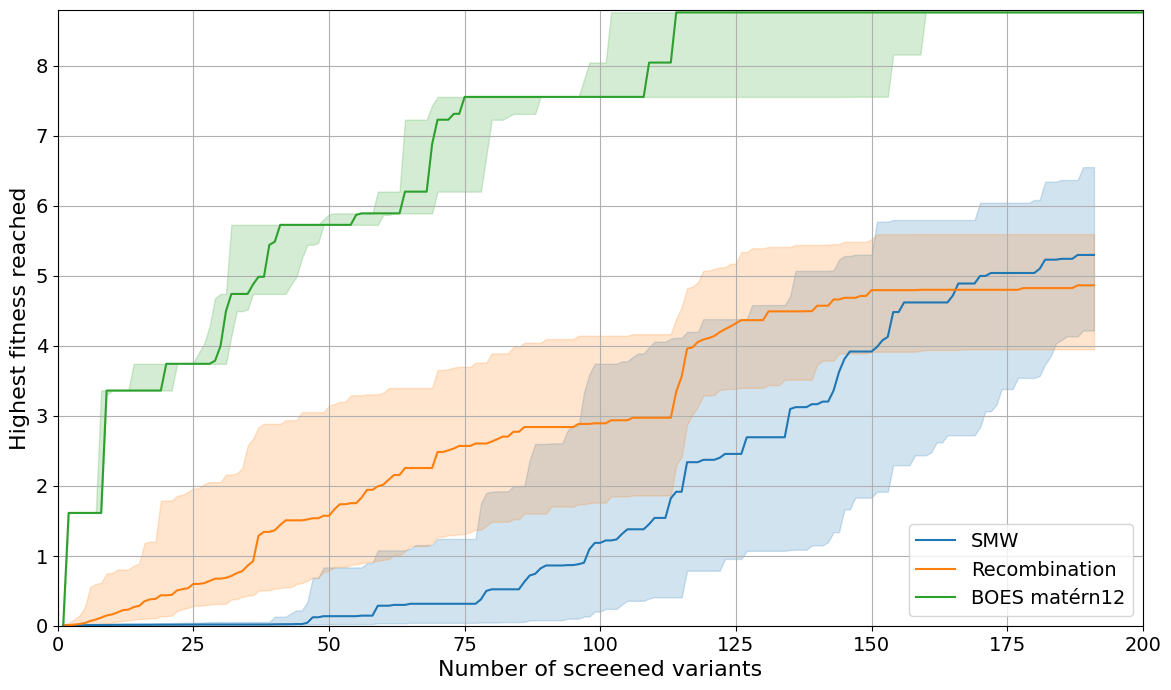

In [127]:

def tsplot(ax, data, label, **kw):
    x = np.arange(data.shape[1]) + 1
    
    #est = np.mean(data, axis=0)
    est = np.median(data, axis=0)
    
    #sd = np.std(data, axis=0)
    #cis = (est - sd, est + sd)
    cis = (np.quantile(data, 0.25, axis=0), np.quantile(data, 0.75, axis=0))

    ax.plot(x,est,**kw,label=label)
    ax.fill_between(x,cis[0],cis[1],alpha=0.2, **kw)
    ax.margins(x=0)

fig, (ax) = plt.subplots(ncols=1, figsize=(14,8), sharey=True)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'blue', 'orange']
i = 0
for fp in all_fitness_progressions:
    tsplot(ax, fp, color=colors[i], label=labels[i])
    i += 1

default_fontsize = 14
label_fontsize = 16
plt.legend(loc=4, fontsize=default_fontsize)
plt.xlabel("Number of screened variants", fontsize=label_fontsize)
plt.ylabel("Highest fitness reached", fontsize=label_fontsize)
plt.xticks(fontsize=default_fontsize)
plt.yticks(fontsize=default_fontsize)
ax.set_ylim(y_limits)
ax.set_xlim([0, 200])
#fig.axes[0].set_aspect(25) # GB1
#fig.axes[0].set_aspect(4) # PhoQ
plt.grid()
plt.show()

fig.savefig('results/' + dataset_name + save_name_modifier + '_fitness_progression.png', bbox_inches='tight') # dpi=300

Plot WT (single) runs

In [128]:
# fig, (ax) = plt.subplots(ncols=1, figsize=(14,7), sharey=True)
# colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:gray']
# i = 0
# for fitness_progression in single_fitness_progressions:
#     ax.plot(np.arange(len(fitness_progression)), fitness_progression, color=colors[i])
#     i += 1
# 
# ax.plot(mlde_od_budgets, mlde_od_best_so_far, 'o ', color=colors[3])
# ax.plot(finetune_budgets, finetune_best_so_far, 'o ', color=colors[4])
# 
# default_fontsize = 14
# label_fontsize = 16
# plt.legend(single_labels, loc=4, fontsize=default_fontsize)
# plt.xlabel("Number of screened variants", fontsize=label_fontsize)
# plt.ylabel("Highest fitness reached", fontsize=label_fontsize)
# plt.xticks(fontsize=default_fontsize)
# plt.yticks(fontsize=default_fontsize)
# ax.set_ylim(y_limits_wt)
# ax.set_xlim([0, 384])
# #fig.axes[0].set_aspect(25) # GB1
# #fig.axes[0].set_aspect(4) # PhoQ
# plt.grid()
# plt.show()

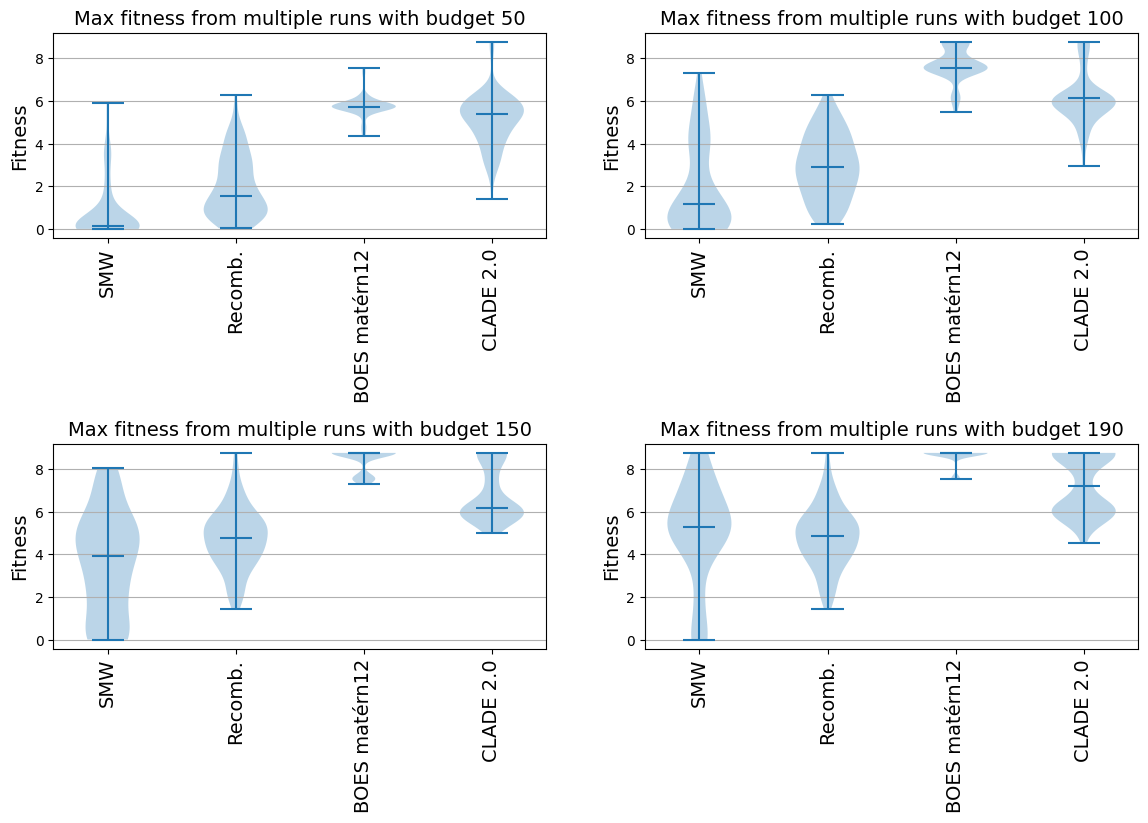

In [129]:
plot_type = 'violin' # 'violin' or 'box'

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), gridspec_kw={'hspace': 1.0})
default_fontsize = 14
budgets = [50, 100, 150, 190]
violin_labels = [l for l in labels]
violin_labels[1] = "Recomb."

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

data_dists = []
for budget in budgets:
    data_dists.append([])
    for fp in all_fitness_progressions:
        data_dists[-1].append(fp[:, budget-1])

if CLADE:
    violin_labels.append("CLADE 2.0")
    for b in range(len(budgets)):
        data_dists[b].append(clade_data_dists[budgets[b]])

a = 0
for ax_row in axs:
    for ax in ax_row:
        if plot_type == 'violin':
            ax.violinplot(
                data_dists[a],
                showmeans=False,
                showmedians=True,
                #quantiles=[[0.25, 0.75]] * len(data_dists[a]),
                #points=100,
            )
        elif plot_type == 'box':
            bplot = ax.boxplot(
                data_dists[a],
                vert=True,  # vertical box alignment
                patch_artist=True,  # fill with color
            )

        # ax.set_title('Violin plot')
        ax.set_title(
            f"Max fitness from multiple runs with budget {budgets[a]}",
            fontsize=default_fontsize,
        )
        ax.yaxis.grid(True)
        ax.set_xticks(
            [y + 1 for y in range(len(data_dists[a]))],
            labels=violin_labels,
            fontsize=default_fontsize,
            rotation='vertical'
        )
        # ax.set_xlabel('')
        ax.set_ylabel("Fitness", fontsize=default_fontsize)

        a += 1

plt.savefig('results/' + dataset_name + save_name_modifier + '_' + plot_type + '.png', bbox_inches='tight') # dpi=300

3
3
['SMW', 'Recomb.', 'BOES matérn12']


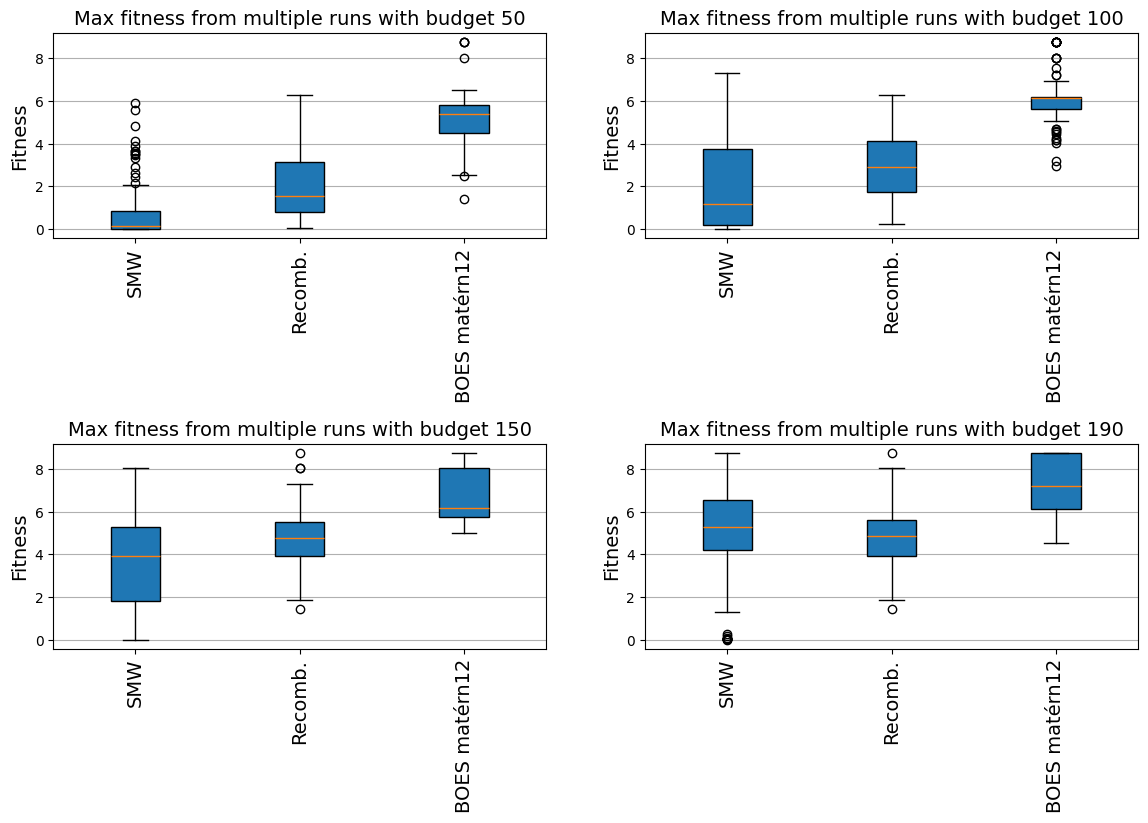

In [130]:
plot_type = 'box' # 'violin' or 'box'

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), gridspec_kw={'hspace': 1.0})
default_fontsize = 14
budgets = [50, 100, 150, 190]
violin_labels = [l for l in labels]
violin_labels[1] = "Recomb."

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

data_dists = []
if CLADE:
    fitprogs = all_fitness_progressions[:-1]
else:
    fitprogs = all_fitness_progressions
for budget in budgets:
    data_dists.append([])
    for fp in fitprogs:
        data_dists[-1].append(fp[:, budget-1])

if CLADE:
   #violin_labels.append("CLADE 2.0")
   for b in range(len(budgets)):
       data_dists[b].append(clade_data_dists[budgets[b]])

print(len(data_dists[0]))
print(len(violin_labels))
print(violin_labels)

a = 0
for ax_row in axs:
    for ax in ax_row:
        if plot_type == 'violin':
            ax.violinplot(
                data_dists[a],
                showmeans=False,
                showmedians=True,
                #quantiles=[[0.25, 0.75]] * len(data_dists[a]),
                #points=100,
            )
        elif plot_type == 'box':
            bplot = ax.boxplot(
                data_dists[a],
                vert=True,  # vertical box alignment
                patch_artist=True,  # fill with color
            )

        # ax.set_title('Violin plot')
        ax.set_title(
            f"Max fitness from multiple runs with budget {budgets[a]}",
            fontsize=default_fontsize,
        )
        ax.yaxis.grid(True)
        ax.set_xticks(
            [y + 1 for y in range(len(data_dists[a]))],
            labels=violin_labels,
            fontsize=default_fontsize,
            rotation='vertical'
        )
        # ax.set_xlabel('')
        ax.set_ylabel("Fitness", fontsize=default_fontsize)

        a += 1

plt.savefig('results/' + dataset_name + save_name_modifier + '_' + plot_type + '.png', bbox_inches='tight') # dpi=300

Table results

(3, 4)


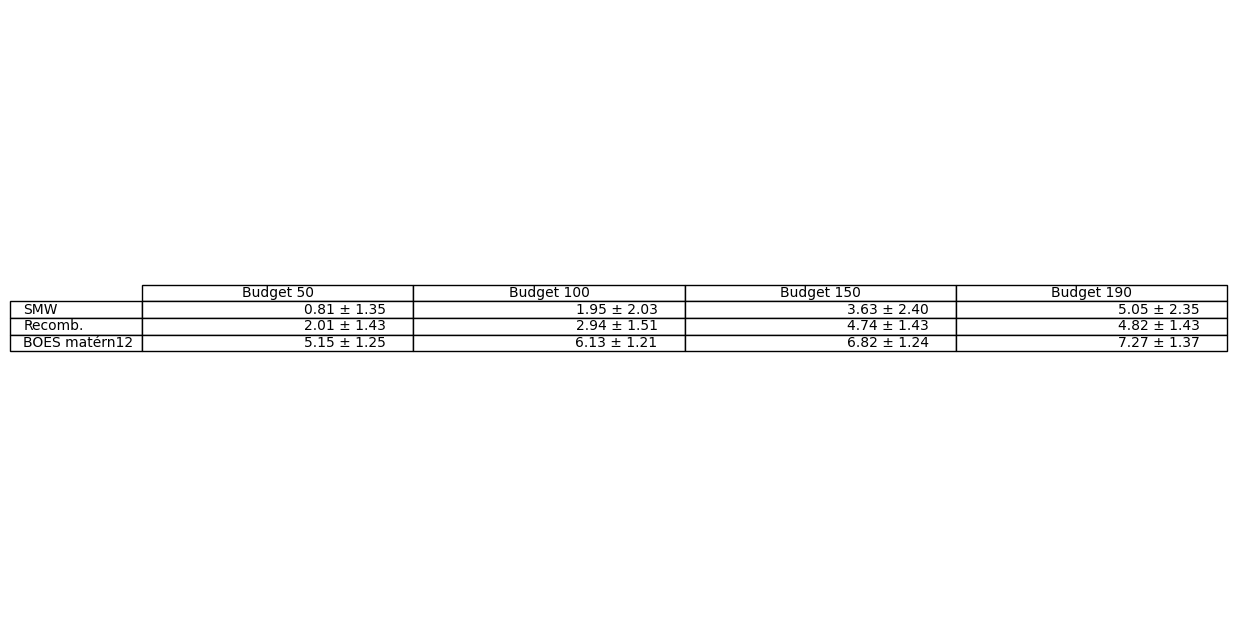

In [131]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 8))

#table_means = [np.mean(fp[:, [b-1 for b in budgets]], axis=0) for fp in all_fitness_progressions]
#table_stds = [np.std(fp[:, [b-1 for b in budgets]], axis=0) for fp in all_fitness_progressions]
table_means = [[np.mean(_dist) for _dist in _dists] for _dists in data_dists]
table_stds = [[np.std(_dist) for _dist in _dists] for _dists in data_dists]
table_data_formatted = [[f"{table_means[b][m]:.2f} ± {table_stds[b][m]:.2f}" for m in range(len(table_means[b]))] for b in range(len(table_means))]
table_data_formatted = np.array(table_data_formatted).T
print(table_data_formatted.shape)
ax.table(cellText=table_data_formatted,
                rowLabels=violin_labels,
                colLabels=[f"Budget {b}" for b in budgets],
                loc='center')
ax.axis('off')

plt.savefig('results/' + dataset_name + save_name_modifier + '_table.png', bbox_inches='tight') # dpi=300